Part 1 Step 3

In [10]:
# Import needed libraries
import yfinance as yf  
import pandas as pd   
import numpy as np     
from sklearn.linear_model import LinearRegression  
from sklearn.model_selection import KFold       
from sklearn.metrics import r2_score             
import matplotlib.pyplot as plt

In [11]:
# Defining the ETF ticker to analyze
ETF_TICKER = "ECH"

# Download historical data for the ECH fund ETF
data = yf.download(ETF_TICKER, start="2019-06-01", end="2024-06-30")

[*********************100%%**********************]  1 of 1 completed


In [12]:
# Calculate daily returns (percentage change in closing price) and shift to align with the next day
# This creates the target variable (y) for prediction
data['Returns'] = data['Close'].pct_change().shift(-1)

# Drop rows with NaN values (resulting from pct_change and shift operations)
data.dropna(inplace=True)

In [13]:
# Feature Engineering: Add a 10-day Simple Moving Average (SMA) as a feature
# SMA is a common technical indicator used to smooth out price data
data['SMA_10'] = data['Close'].rolling(10).mean()

# Drop rows with NaN values again (since the first 10 rows will have NaN for SMA_10)
data.dropna(inplace=True)

In [14]:
# Define features (X) and target (y)
# X: 10-day SMA values
# y: Next-day returns
X = data[['SMA_10']].values  
y = data['Returns'].values

In [15]:
# Initialize 5-fold cross-validation
kf = KFold(n_splits=5)

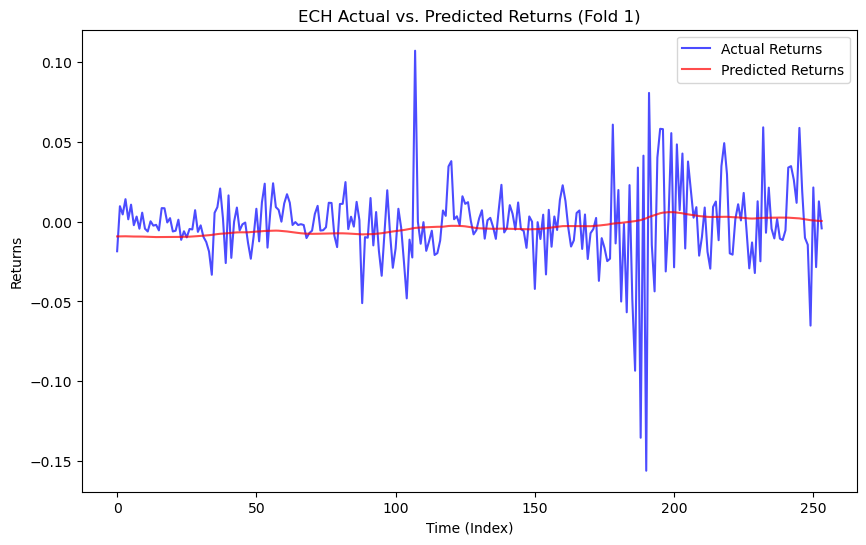

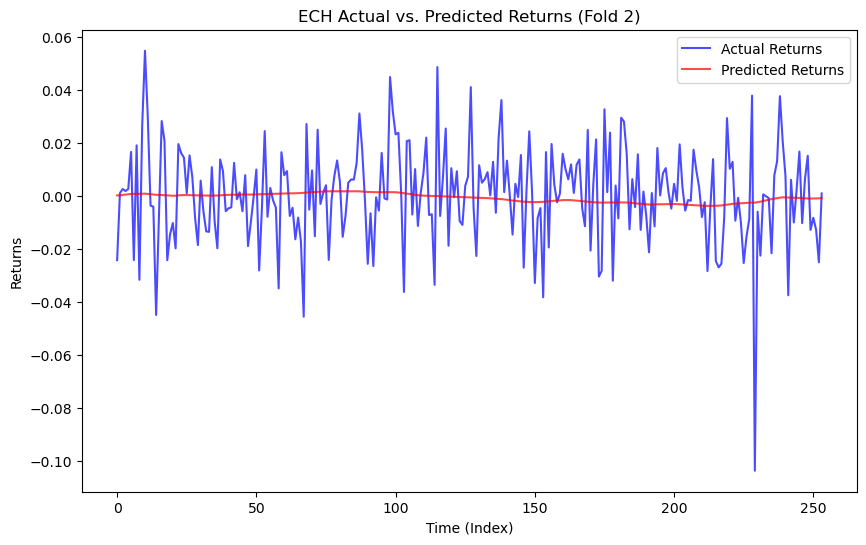

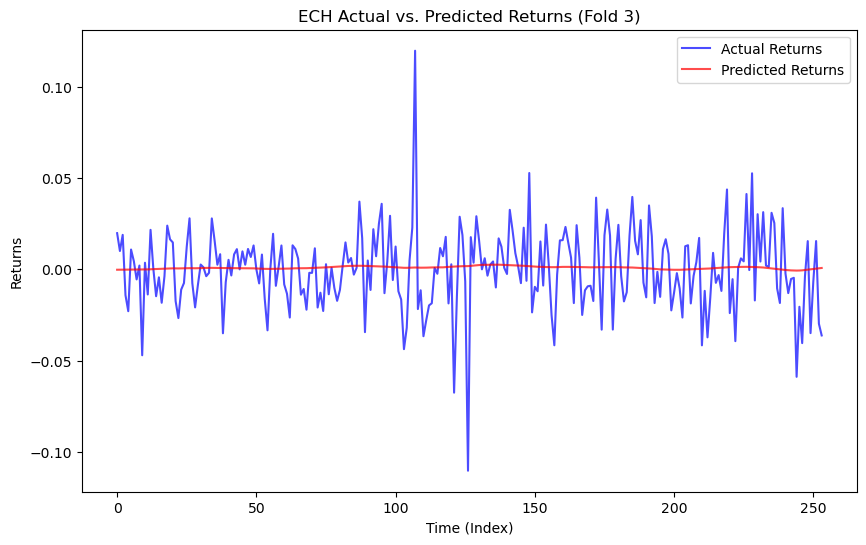

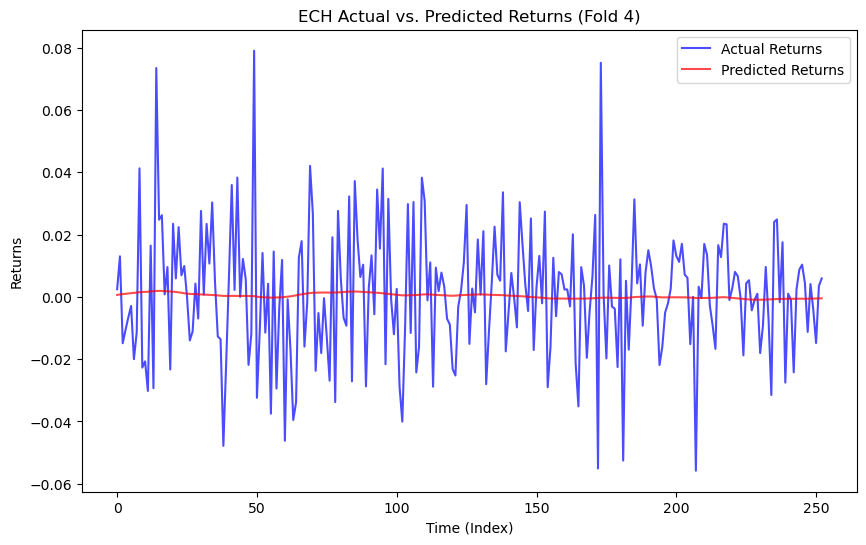

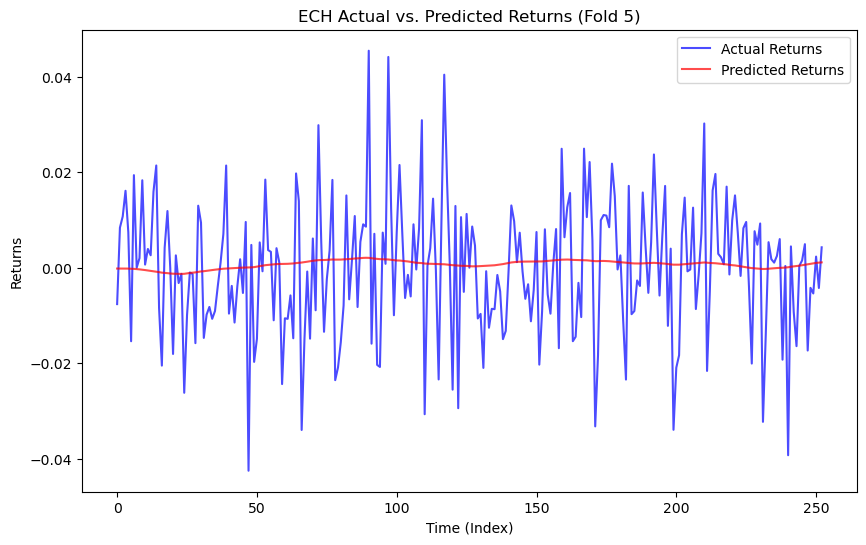

In [16]:
# Lists to store correlation and R-squared scores for each fold
correlations, r2_scores = [], []
# Perform 5-fold cross-validation
for train_idx, test_idx in kf.split(X):
    # Split data into training and testing sets for the current fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Initialize a linear regression model
    model = LinearRegression()
    
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Predict next-day returns using the test set
    y_pred = model.predict(X_test)
    
    # Calculate correlation between predicted and actual returns
    correlation = np.corrcoef(y_pred, y_test)[0, 1]
    correlations.append(correlation)
    
    # Calculate R-squared score to evaluate model performance
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

    # Plot actual vs. predicted returns for the current fold
    plt.figure(figsize=(10, 6))
    plt.plot(y_test, label="Actual Returns", color="blue", alpha=0.7)
    plt.plot(y_pred, label="Predicted Returns", color="red", alpha=0.7)
    plt.xlabel("Time (Index)")
    plt.ylabel("Returns")
    plt.title(f"{ETF_TICKER} Actual vs. Predicted Returns (Fold {len(correlations)})")
    plt.legend()
    plt.show()

In [17]:
# Create a results table with ETF column
results = pd.DataFrame({
    'ETF': ETF_TICKER,  # Add ETF column
    'Fold': range(1, 6),  # Fold numbers (1 to 5)
    'Correlation': correlations,  # Correlation for each fold
    'R²': r2_scores  # R-squared for each fold
})

In [18]:
# Print the results table
print("Cross-Validation Results:")
print(results)

Cross-Validation Results:
   ETF  Fold  Correlation        R²
0  ECH     1     0.086911 -0.006416
1  ECH     2     0.079544  0.002774
2  ECH     3     0.170414  0.007074
3  ECH     4     0.117058  0.006561
4  ECH     5     0.118882  0.005257


Part 2 Step 5 & 6

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [20]:
#Load credit data from a CSV file into a pandas DataFrame and structure it into useful formats
def import_credit_data(csv_file):
    try:
        df = pd.read_csv(csv_file)
        print("Data successfully loaded.")
        
        # Fill missing values with appropriate defaults
        df.fillna({
            'person_age': df['person_age'].median(),
            'person_income': df['person_income'].mean(),
            'loan_amnt': df['loan_amnt'].mean(),
            'loan_int_rate': df['loan_int_rate'].median(),
            'cb_person_cred_hist_length': df['cb_person_cred_hist_length'].median()
        }, inplace=True)
        
        # Convert categorical data to category type
        categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'loan_status', 'cb_person_default_on_file']
        for col in categorical_cols:
            if col in df.columns:
                df[col] = df[col].astype('category')
        
        print("Data successfully structured.")
        return df
    except Exception as e:
        print(f"Error loading or structuring data: {e}")
        return None

In [21]:
#Perform exploratory data analysis on the credit dataset
def exploratory_data_analysis(df):
    print("\nSummary Statistics:")
    print(df.describe())
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    # Distribution plots
    plt.figure(figsize=(12, 6))
    sns.histplot(df['loan_amnt'], bins=20, kde=True)
    plt.title("Loan Amount Distribution")
    plt.show()
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='loan_grade', y='loan_int_rate', data=df)
    plt.title("Loan Interest Rate by Loan Grade")
    plt.show()
    
    plt.figure(figsize=(12, 6))
    sns.histplot(df['cb_person_cred_hist_length'], bins=30, kde=True)
    plt.title("Credit History Length Distribution")
    plt.show()

In [22]:
# Sample data from Kaggle Credit Risk Dataset by Lao Tse
csv_path = 'C:/Users/keega/Documents/credit_risk_dataset.csv'
data = import_credit_data(csv_path)
print(data.head())

Data successfully loaded.
Data successfully structured.
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate loan_status  \
0    PERSONAL          D      35000          16.02           1   
1   EDUCATION          B       1000          11.14           0   
2     MEDICAL          C       5500          12.87           1   
3     MEDICAL          C      35000          15.23           1   
4     MEDICAL          C      35000          14.27           1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59       


Summary Statistics:
         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  
count   32581.000000         32581.000000                32581.000000  
mean       11.009620             0.170203                    5.804211  
std         3.081611             0.106782                    4.055001  
min         5.420000             0.000000          

c:\Users\keega\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


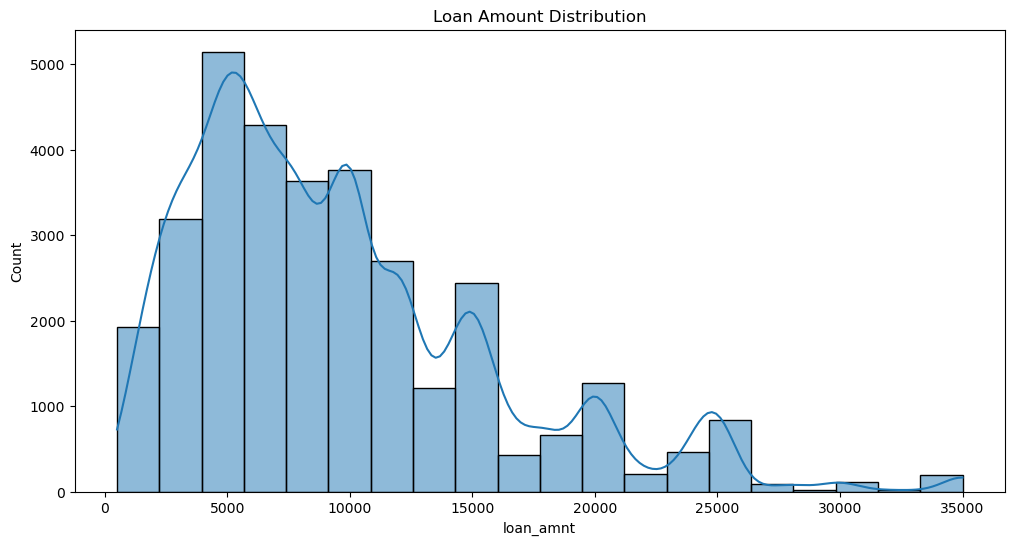

c:\Users\keega\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


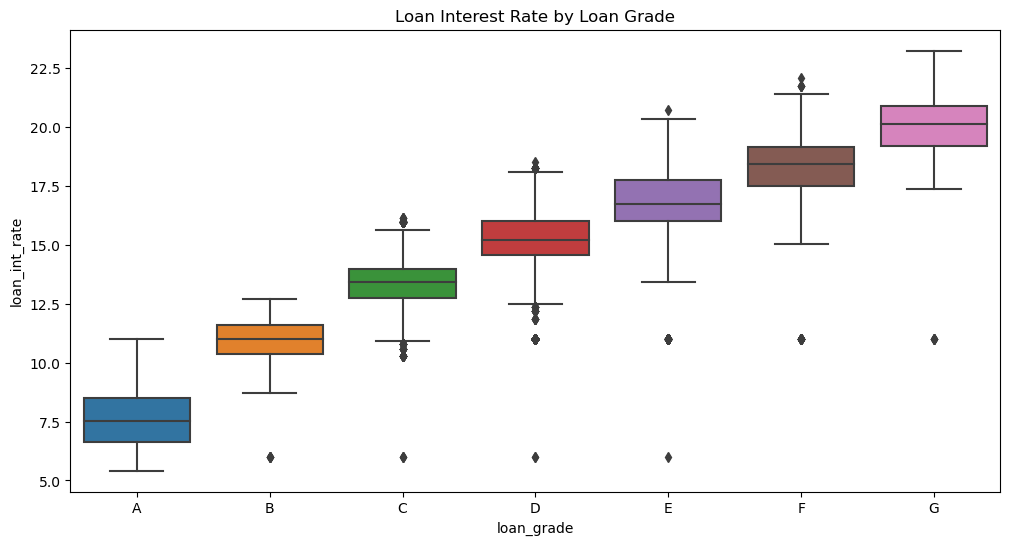

c:\Users\keega\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


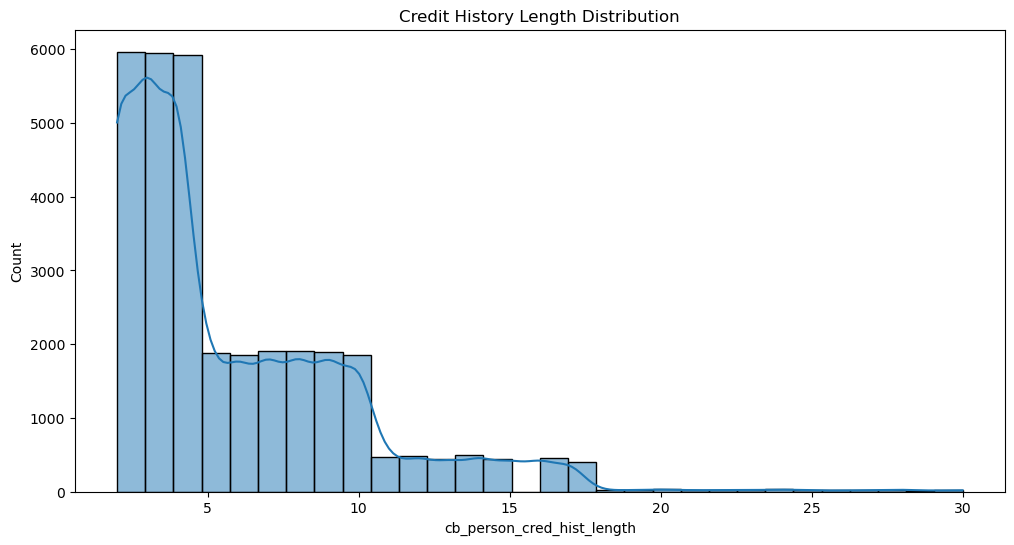

In [23]:
if data is not None:
    exploratory_data_analysis(data)